# Enterprise Loan Risk Intelligence Platform

## Phase 2 - Exploratory Data Analysis (EDA)

### 1. Import Libraries

### 2. Load Dataset

### 3. Initial Data Inspection

### 4. Data Quality Assessment

### 5. Missing Value Analysis

### 6. Duplicate Analysis

### 7. Target Variable Analysis

### 8. Numerical Feature Analysis

### 9. Categorical Feature Analysis

### 10. Correlation Analysis

### 11. Key Insights

In [15]:
import warnings 
warnings.filterwarnings("ignore")

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno # Missing data visualization

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.style.use('ggplot')


In [17]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'loan_data.csv'

df = pd.read_csv(DATA_PATH,
                 low_memory=False)

In [18]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt cons

In [19]:
df.shape

(2260668, 145)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), str(36)
memory usage: 2.4 GB


In [21]:
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260663,NaN,NaN,12000,12000,12000.0,60 months,14.08,279.72,C,C3,house keeper,10+ years,MORTGAGE,58000.0,Not Verified,Oct-2017,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,054xx,VT,20.88,0.0,Jan-2004,0.0,NaN,NaN,12.0,0.0,9592,39.2,34.0,w,8687.20,8687.20,5360.960000,5360.96,3312.80,2048.16,0.0,0.0,0.0,Feb-2019,279.72,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,7921.0,45212.0,2.0,2.0,0.0,1.0,24.0,35620.0,36.0,3.0,4.0,4052.0,38.0,24500.0,2.0,2.0,1.0,5.0,4110.0,1807.0,70.9,0.0,0.0,157.0,164.0,1.0,1.0,2.0,9.0,NaN,9.0,NaN,0.0,2.0,4.0,3.0,9.0,11.0,10.0,21.0,4.0,12.0,0.0,0.0,0.0,3.0,100.0,66.7,0.0,0.0,73948.0,45212.0,6200.0,49448.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260664,NaN,NaN,12000,12000,12000.0,60 months,25.82,358.01,E,E4,Skilled Labor,< 1 year,MORTGAGE,30000.0,Not Verified,Oct-2017,Fully Paid,n,NaN,NaN,debt_consolidation,Debt consolidation,971xx,OR,19.28,3.0,Mar-2003,1.0,13.0,NaN,10.0,0.0,3497,20.2,26.0,w,0.00,0.00,14499.802172,14499.80,12000.00,2499.80,0.0,0.0,0.0,Aug-2018,182.74,NaN,Sep-2017,0.0,46.0,1,Joint App,135000.0,7.36,Not Verified,0.0,550.0,346404.0,0.0,1.0,1.0,1.0,8.0,9431.0,78.0,0.0,3.0,2238.0,44.0,17300.0,5.0,1.0,7.0,4.0,34640.0,9162.0,19.6,0.0,0.0,163.0,174.0,16.0,8.0,4.0,141.0,46.0,0.0,17.0,2.0,1.0,4.0,2.0,5.0,4.0,7.0,18.0,4.0,10.0,0.0,0.0,0.0,1.0,76.9,50.0,0.0,0.0,382275.0,12928.0,11400.0,12125.0,13710.0,Apr-2003,1.0,4.0,11.0,71.6,1.0,17.0,0.0,0.0,7.0,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260665,NaN,NaN,10000,10000,10000.0,36 months,11.99,332.10,B,B5,Teacher,10+ years,OWN,64000.0,Sour

In [22]:
df.sample(5,random_state=42)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1758049,NaN,NaN,35000,35000,35000.0,36 months,12.12,1164.51,B,B3,Legacy Physicians Group,< 1 year,RENT,90000.0,Verified,Jun-2013,Fully Paid,n,NaN,NaN,debt_consolidation,Hospital Debt,775xx,TX,3.51,0.0,Nov-1997,0.0,26.0,NaN,14.0,0.0,1347,8.1,22.0,w,0.00,0.00,36606.090000,36606.09,35000.00,1606.09,0.0,0.0,0.0,Dec-2013,4783.54,NaN,Jan-2014,0.0,26.0,1,Individual,NaN,NaN,NaN,0.0,0.0,81768.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16700.0,NaN,NaN,NaN,1.0,5841.0,12053.0,10.1,0.0,0.0,169.0,190.0,12.0,12.0,1.0,55.0,NaN,NaN,NaN,1.0,1.0,1.0,2.0,3.0,14.0,5.0,7.0,1.0,14.0,0.0,0.0,0.0,1.0,95.0,0.0,0.0,0.0,99068.0,81768.0,13400.0,82368.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
686533,NaN,NaN,30000,30000,30000.0,60 months,10.75,648.54,B,B4,Director of nursing,2 years,RENT,100000.0,Verified,Apr-2016,Current,n,NaN,NaN,credit_card,Credit card refinancing,782xx,TX,22.85,0.0,Jun-2011,2.0,NaN,NaN,17.0,0.0,29780,52.7,25.0,f,14987.66,14987.66,22115.610000,22115.61,15012.34,7103.27,0.0,0.0,0.0,Feb-2019,648.54,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,65689.0,0.0,2.0,0.0,1.0,22.0,35909.0,64.0,0.0,3.0,7525.0,58.0,56500.0,4.0,9.0,5.0,4.0,3864.0,12126.0,60.6,0.0,0.0,49.0,57.0,13.0,13.0,0.0,25.0,NaN,0.0,NaN,0.0,6.0,10.0,7.0,8.0,7.0,15.0,18.0,10.0,17.0,0.0,0.0,0.0,0.0,100.0,57.1,0.0,0.0,113051.0,65689.0,30800.0,56551.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
900721,NaN,NaN,15000,15000,15000.0,36 months,7.49,466.53,A,A4,Partner,5 years,OWN,100000.0,Source Verified,Oct-2016,Fully Paid,n,NaN,NaN,sm

In [24]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.000,20000.0000,40000.00
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.000,20000.0000,40000.00
funded_amnt_inv,2260668.0,15023.437624,9192.331807,0.00,8000.00,12800.000,20000.0000,40000.00
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10613.0,11628.036442,7615.161123,55.73,5628.73,10044.220,16114.9400,40306.41
hardship_last_payment_amount,10613.0,193.606331,198.694368,0.01,43.78,132.890,284.1800,1407.86
settlement_amount,33056.0,5030.606922,3692.027842,44.21,2227.00,4172.855,6870.7825,33601.00
settlement_percentage,33056.0,47.775600,7.336379,0.20,45.00,45.000,50.0000,521.35


In [25]:
df.describe(include='str').T 

,count,unique,top,freq
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
emp_length,2113761,11,10+ years,748005
home_ownership,2260668,6,MORTGAGE,1111450
verification_status,2260668,3,Source Verified,886231
issue_d,2260668,139,Mar-2016,61992
loan_status,2260668,9,Fully Paid,1041952
pymnt_plan,2260668,2,n,2259986


In [27]:
df.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [28]:
len(df.columns) # same as in shape 

145

In [29]:
df.dtypes.value_counts()

float64    105
str         36
int64        4
Name: count, dtype: int64

In [30]:
memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory Usage: {memory_usage:.2f} MB")

Memory Usage: 5554.15 MB


## Initial Observations

- Dataset contains approximately 200k+ loan records.
- Total features: 145.
- Dataset occupies approximately 5.5 GB in memory.
- Most columns are numerical (`float64`), followed by categorical (`object`) columns.
- Large dataset size suggests careful memory optimization will be beneficial during preprocessing.

In [34]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='Missing Values')  # Convert series to DataFrame and rename the column
)

In [35]:
missing['missing %'] = (
    missing['Missing Values'] / len(df) * 100
)

In [36]:
missing.head(20)

,Missing Values,missing %
id,2260668,100.000000
member_id,2260668,100.000000
url,2260668,100.000000
orig_projected_additional_accrued_interest,2252242,99.627278
hardship_amount,2250055,99.530537
hardship_dpd,2250055,99.530537
hardship_loan_status,2250055,99.530537
deferral_term,2250055,99.530537
hardship_end_date,2250055,99.530537
hardship_status,2250055,99.530537


In [38]:
(missing['Missing Values'] > 0).sum()

np.int64(113)

#### 113 Columns have Missing Values

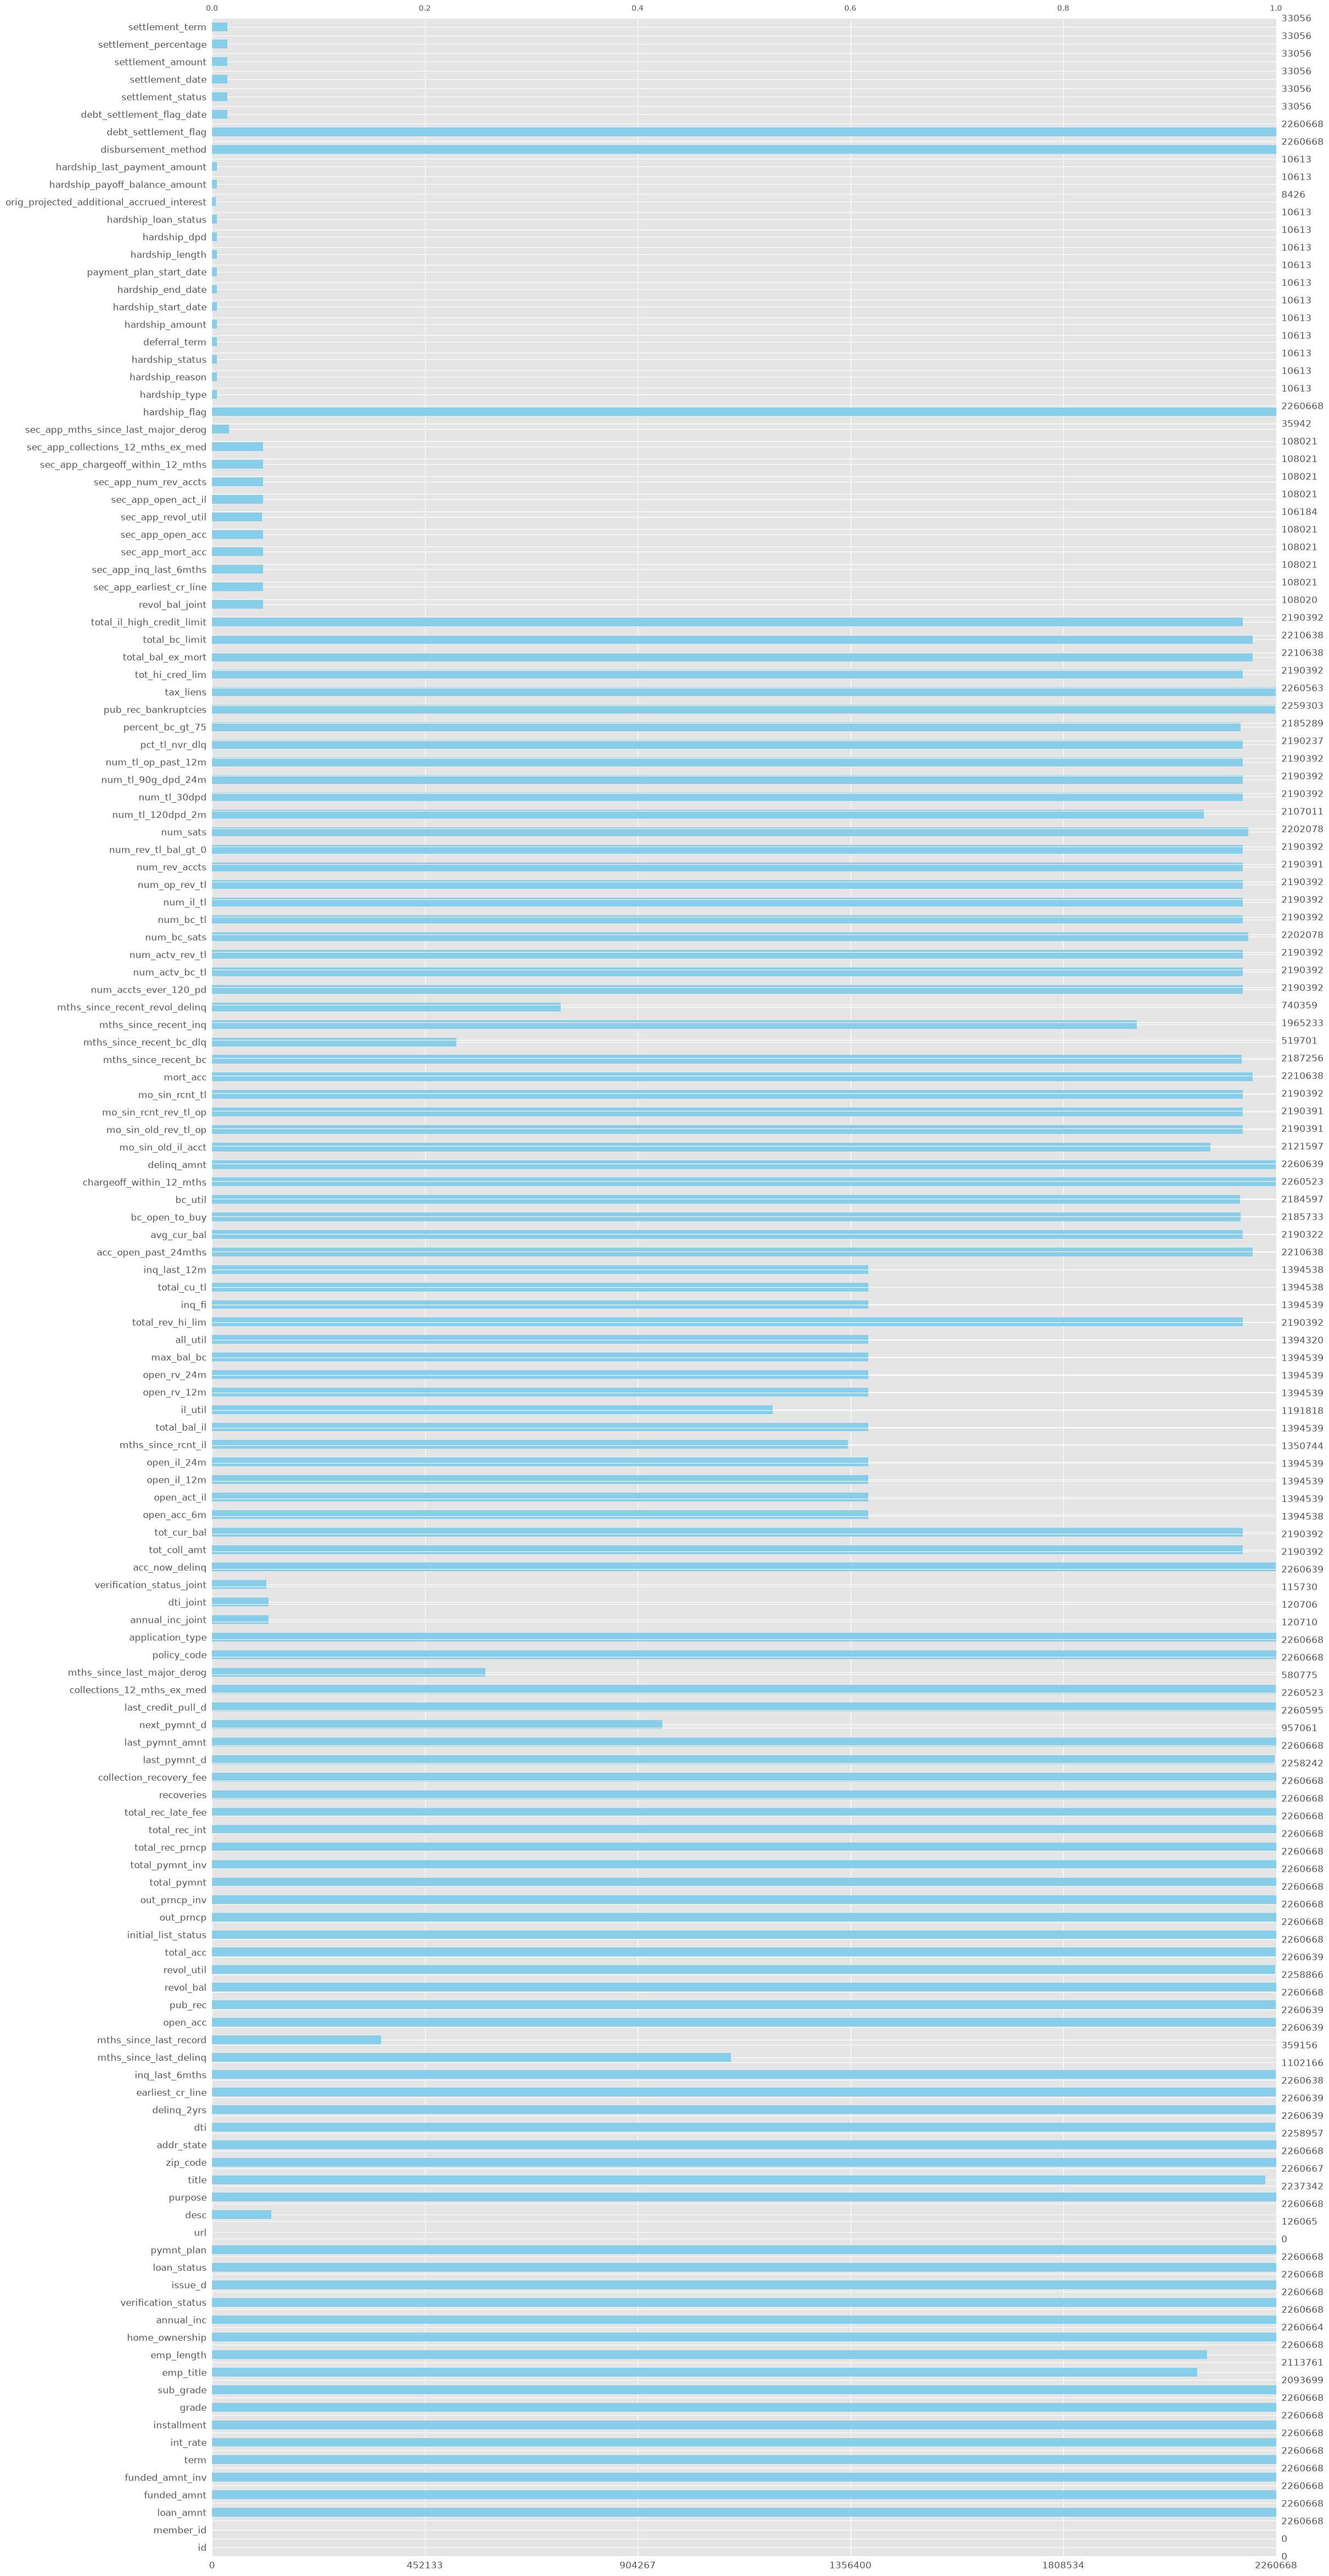

In [39]:
plt.figure(figsize=(12, 6))
msno.bar(df, color='skyblue', fontsize=12)
plt.show()

In [40]:
df.duplicated().sum()

np.int64(0)

In [42]:
unique = pd.DataFrame({
    'Unique Values':  df.nunique()
}).sort_values('Unique Values')

In [43]:
unique.head()

,Unique Values
id,0
member_id,0
url,0
policy_code,1
hardship_type,1


In [44]:
[col for col in df.columns if 'loan_status' in col.lower()]

['loan_status', 'hardship_loan_status']

In [45]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [46]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
Fully Paid                                             46.090448
Current                                                40.682444
Charged Off                                            11.574234
Late (31-120 days)                                      0.968608
In Grace Period                                         0.395989
Late (16-30 days)                                       0.165305
Does not meet the credit policy. Status:Fully Paid      0.087939
Does not meet the credit policy. Status:Charged Off     0.033663
Default                                                 0.001371
Name: proportion, dtype: float64

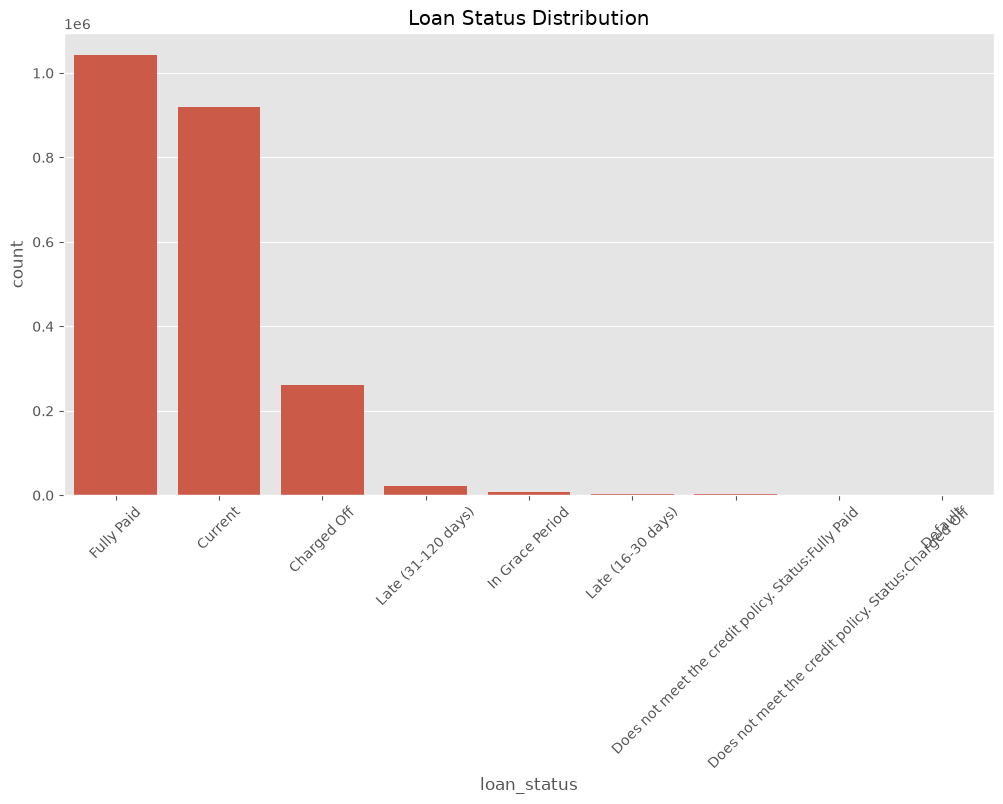

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='loan_status', order=df['loan_status'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Loan Status Distribution')
plt.show()

In [48]:
leakage_keywords = [
    "payment",
    "recover",
    "collection",
    "settlement",
    "last",
    "next",
    "total",
    "out_prncp",
    "hardship",
    "pymnt"
]

for col in df.columns:
    if any(keyword in col.lower() for keyword in leakage_keywords):
        print(col)

pymnt_plan
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
total_acc
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
mths_since_last_major_derog
total_bal_il
total_rev_hi_lim
total_cu_tl
inq_last_12m
total_bal_ex_mort
total_bc_limit
total_il_high_credit_limit
sec_app_inq_last_6mths
sec_app_collections_12_mths_ex_med
sec_app_mths_since_last_major_derog
hardship_flag
hardship_type
hardship_reason
hardship_status
hardship_amount
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_length
hardship_dpd
hardship_loan_status
hardship_payoff_balance_amount
hardship_last_payment_amount
debt_settlement_flag
debt_settlement_flag_date
settlement_status
settlement_date
settlement_amount
settlement_percentage
settlement_term


## Target Variable Observations

- Target column: loan_status
- Examined class distribution.
- Reviewed target definition using the data dictionary.
- Identified potential data leakage columns for future preprocessing.

In [49]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['str']).columns.tolist()

print(f"Numeric Features: {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")


Numeric Features: 109
Categorical Features: 36


In [50]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.000,20000.0000,40000.00
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.000,20000.0000,40000.00
funded_amnt_inv,2260668.0,15023.437624,9192.331807,0.00,8000.00,12800.000,20000.0000,40000.00
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10613.0,11628.036442,7615.161123,55.73,5628.73,10044.220,16114.9400,40306.41
hardship_last_payment_amount,10613.0,193.606331,198.694368,0.01,43.78,132.890,284.1800,1407.86
settlement_amount,33056.0,5030.606922,3692.027842,44.21,2227.00,4172.855,6870.7825,33601.00
settlement_percentage,33056.0,47.775600,7.336379,0.20,45.00,45.000,50.0000,521.35


In [51]:
df[categorical_features].describe().T

,count,unique,top,freq
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
emp_length,2113761,11,10+ years,748005
home_ownership,2260668,6,MORTGAGE,1111450
verification_status,2260668,3,Source Verified,886231
issue_d,2260668,139,Mar-2016,61992
loan_status,2260668,9,Fully Paid,1041952
pymnt_plan,2260668,2,n,2259986


In [52]:
skewness = (df[numeric_features]
            .skew()
            .sort_values(ascending=False)
)

skewness.head(20)

tot_coll_amt                          852.010132
annual_inc                            493.886088
delinq_amnt                           102.654774
num_tl_120dpd_2m                       55.809847
total_rev_hi_lim                       32.557427
tax_liens                              32.070911
dti                                    29.201854
acc_now_delinq                         22.907978
num_tl_30dpd                           22.517463
total_rec_late_fee                     21.845867
annual_inc_joint                       21.744536
sec_app_chargeoff_within_12_mths       20.276993
chargeoff_within_12_mths               18.128548
num_tl_90g_dpd_24m                     14.901574
collections_12_mths_ex_med             14.032574
max_bal_bc                             13.695399
sec_app_collections_12_mths_ex_med     13.300922
revol_bal                              13.231988
collection_recovery_fee                11.808699
pub_rec                                11.376808
dtype: float64

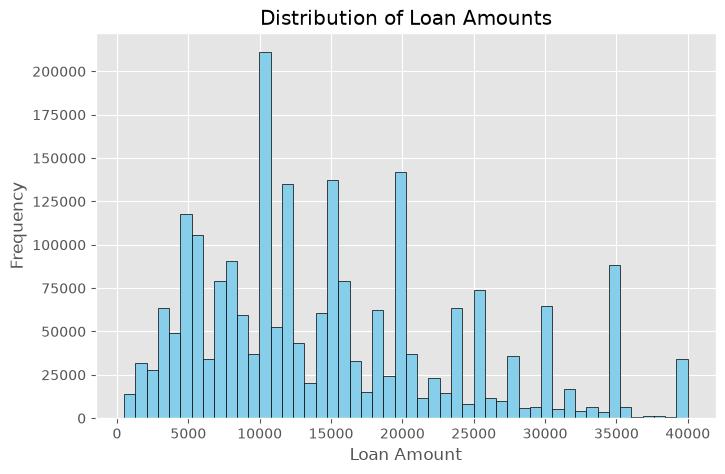

In [54]:
plt.figure(figsize=(8,5))
plt.hist(df['loan_amnt'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()


Loan amounts are concentrated around standard lending amounts rather than being continuously distributed.

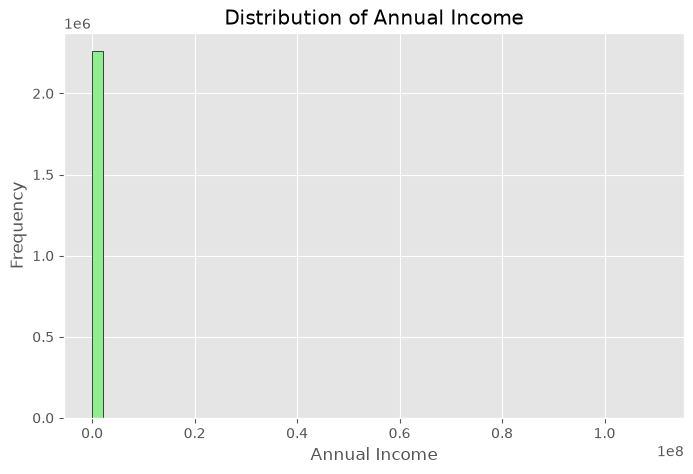

In [55]:
plt.figure(figsize=(8, 5))
plt.hist(df['annual_inc'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

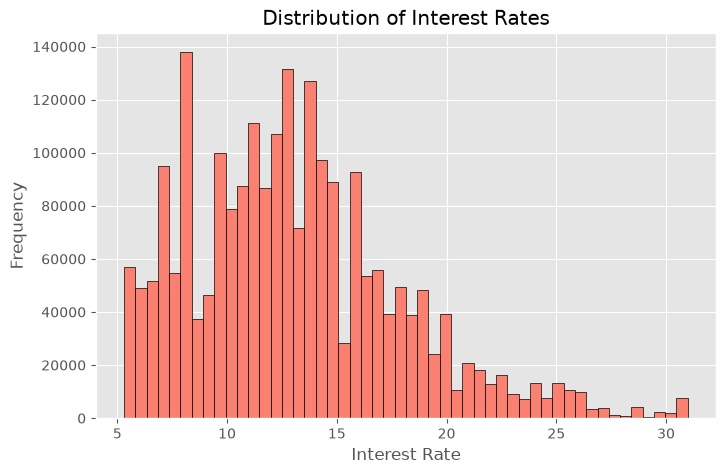

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(df['int_rate'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of Interest Rates')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='annual_inc', ylabel='Count'>

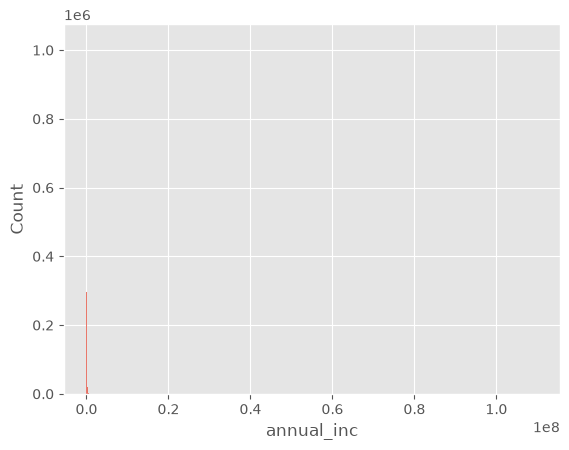

In [58]:
sns.histplot(df['annual_inc'])

In [59]:
df["annual_inc"].describe(percentiles=[0.90,0.95,0.99,0.999])

count    2.260664e+06
mean     7.799243e+04
std      1.126962e+05
min      0.000000e+00
90%      1.300000e+05
95%      1.600000e+05
99%      2.700000e+05
99.9%    6.000000e+05
max      1.100000e+08
Name: annual_inc, dtype: float64

In [60]:
df['annual_inc'].nlargest(10) #gives the top 10 largest values in the 'annual_inc' column

1519700    110000000.0
1369278     61000000.0
1458483     10999200.0
372715       9930475.0
61127        9757200.0
675605       9573072.0
714651       9550000.0
1381011      9522972.0
1160644      9500000.0
1351377      9300086.0
Name: annual_inc, dtype: float64

In [61]:
(df['annual_inc'] > 1_000_000).sum() #gives the count of values greater than 1 million in the 'annual_inc' column

np.int64(583)

In [63]:
((df['annual_inc'] > 1_000_000).mean()) * 100

np.float64(0.02578883763560151)

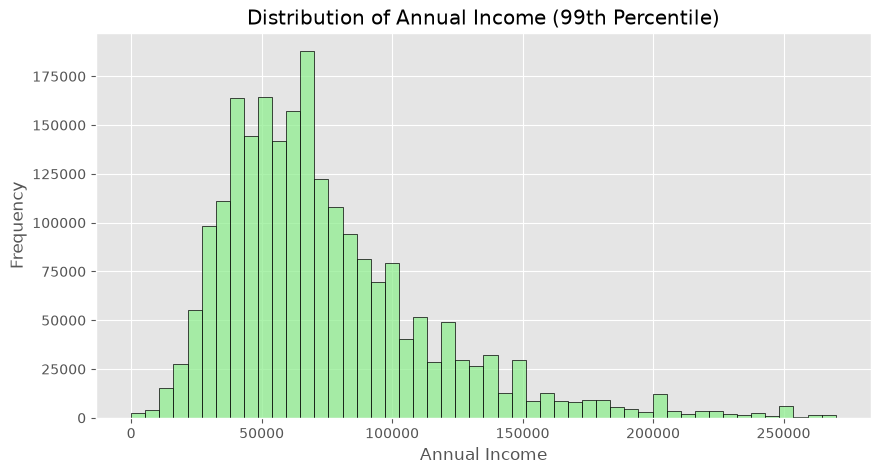

In [64]:
income_99 = df['annual_inc'].quantile(0.99)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['annual_inc'] <= income_99]['annual_inc'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of Annual Income (99th Percentile)')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

In [66]:
loan_df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
loan_df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1}).value_counts()

loan_status
0    1041952
1     261655
Name: count, dtype: int64

In [67]:
loan_df['loan_status'].value_counts(normalize=True) * 100

loan_status
Fully Paid     79.928383
Charged Off    20.071617
Name: proportion, dtype: float64

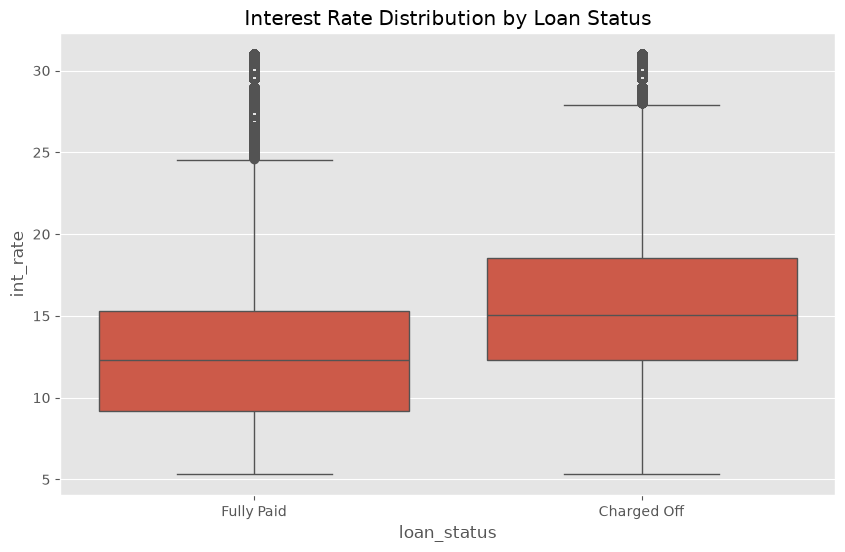

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=loan_df,
            x='loan_status',
            y='int_rate')
plt.xticks([0,1], ['Fully Paid', 'Charged Off'])
plt.title('Interest Rate Distribution by Loan Status')
plt.show()

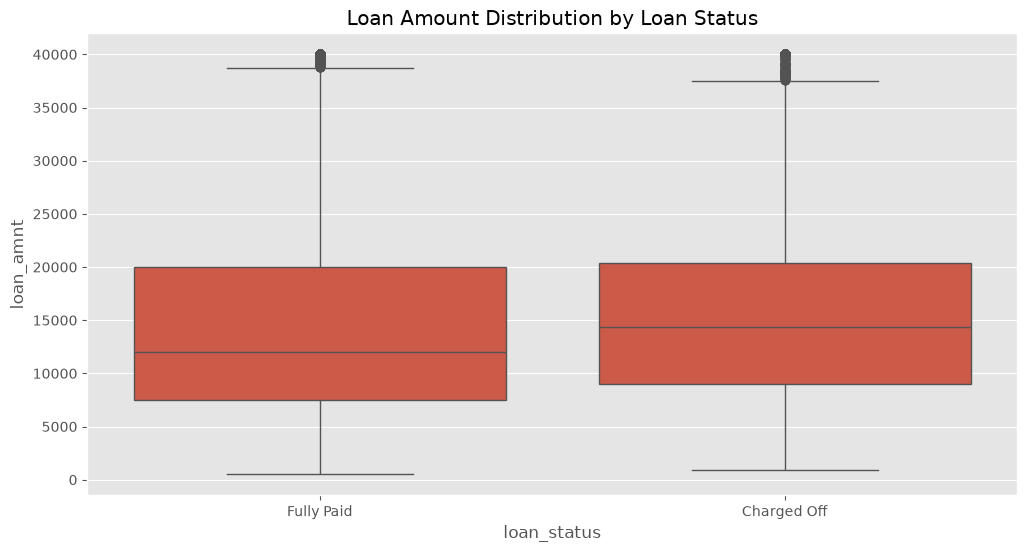

In [70]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=loan_df, x='loan_status', y='loan_amnt')
plt.xticks([0,1], ['Fully Paid', 'Charged Off'])
plt.title('Loan Amount Distribution by Loan Status')
plt.show()

### Observation – Interest Rate

- Charged Off loans generally have higher interest rates than Fully Paid loans.
- The median interest rate for defaulted loans is noticeably higher.
- Interest rate appears to be a strong predictor of loan default.

In [71]:
grade_default = pd.crosstab(loan_df['grade'], loan_df['loan_status'], normalize='index') * 100

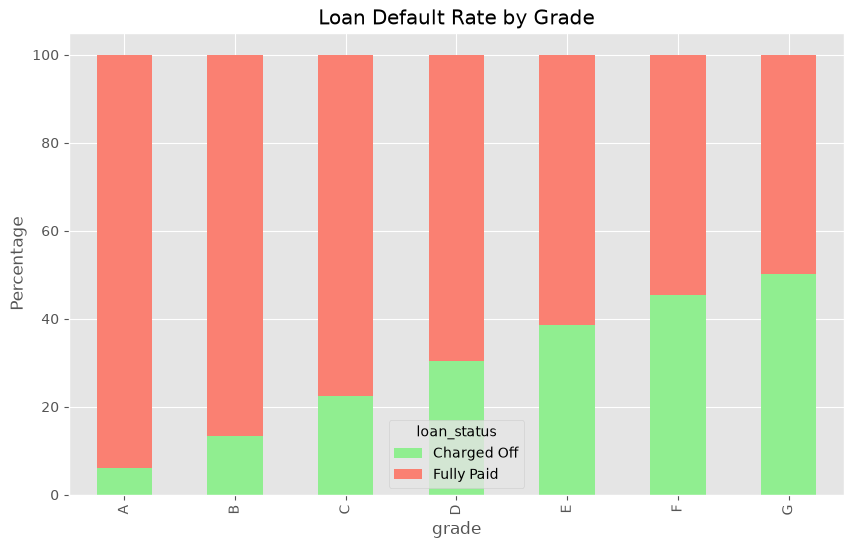

In [76]:
grade_default.plot(kind='bar', stacked=True, figsize=(10, 6), color=['lightgreen', 'salmon'])
plt.title('Loan Default Rate by Grade')
plt.ylabel('Percentage')
plt.show()

### Observation – Loan Grade

- Default rates increase steadily from Grade A to Grade G.
- Grade A loans have the lowest default rate (~6%).
- Grade G loans have the highest default rate (~50%).
- Loan grade appears to be a strong predictor of loan default.

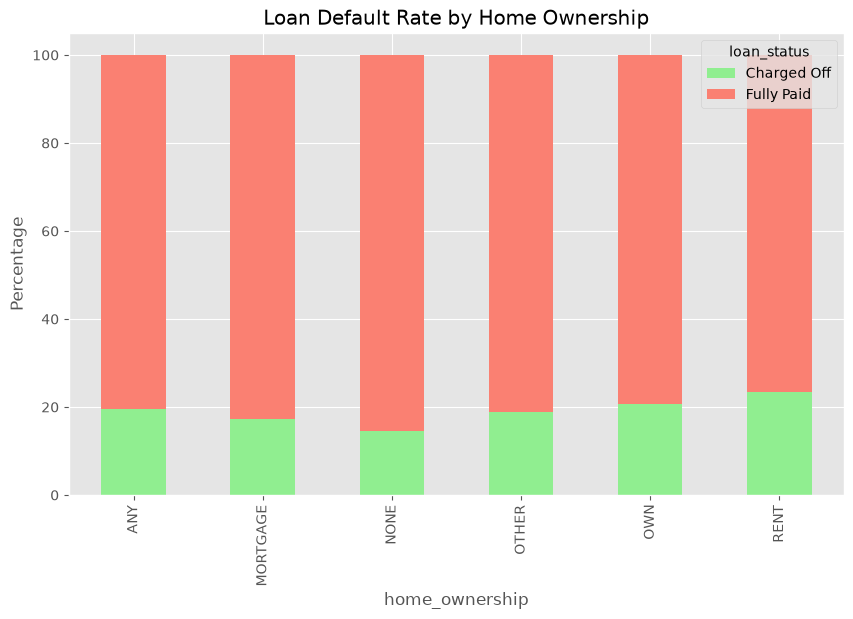

In [77]:
home_default = pd.crosstab(loan_df['home_ownership'], loan_df['loan_status'], normalize='index') * 100
home_default.plot(kind='bar', stacked=True, figsize=(10, 6), color=['lightgreen', 'salmon'])
plt.title('Loan Default Rate by Home Ownership')
plt.ylabel('Percentage')
plt.show()

### Observation – Home Ownership

- Borrowers who rent their homes exhibit the highest default rate.
- Borrowers with mortgages have comparatively lower default rates.
- Home ownership may contribute useful information to the predictive model.
- Categories such as `ANY` and `OTHER` should be checked for sample size before drawing strong conclusions.

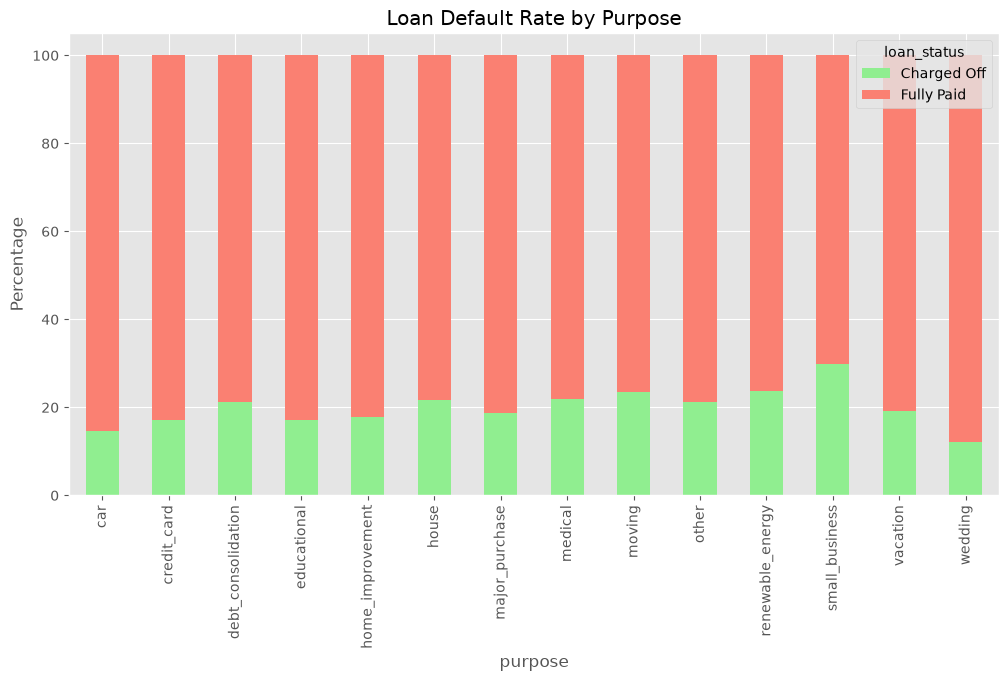

In [78]:
purpose_default = pd.crosstab(loan_df['purpose'], loan_df['loan_status'], normalize='index') * 100
purpose_default.plot(kind='bar', stacked=True, figsize=(12, 6), color=['lightgreen', 'salmon'])
plt.title('Loan Default Rate by Purpose')
plt.ylabel('Percentage')
plt.show()

### Observation – Loan Purpose

- Default rates vary across loan purposes.
- Small business loans have the highest observed default rate.
- Wedding and car loans show comparatively lower default rates.
- Loan purpose appears to be a useful categorical feature for predicting default.

In [79]:
important_numeric = [
      "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "installment",
    "fico_range_low",
    "fico_range_high",
    "revol_bal",
    "revol_util",
    "open_acc",
    "total_acc",
    "loan_status"
]

In [81]:
available_cols = [col for col in important_numeric if col in loan_df.columns]

corr_df = loan_df[available_cols].copy()

if "loan_status" in corr_df.columns:
    corr_df["loan_status"] = corr_df["loan_status"].map({"Fully Paid": 0, "Charged Off": 1})

corr = corr_df.corr(numeric_only=True)
corr

,loan_amnt,int_rate,annual_inc,dti,installment,revol_bal,revol_util,open_acc,total_acc,loan_status
loan_amnt,1.000000,0.143817,0.310231,0.032084,0.953352,0.318618,0.108465,0.186319,0.208991,0.065217
int_rate,0.143817,1.000000,-0.071267,0.148388,0.155512,-0.027675,0.242760,-0.003865,-0.042266,0.258412
annual_inc,0.310231,-0.071267,1.000000,-0.141383,0.300992,0.284175,0.034613,0.133669,0.174804,-0.041716
dti,0.032084,0.148388,-0.141383,1.000000,0.035679,0.111136,0.143311,0.229022,0.176409,0.087174
installment,0.953352,0.155512,0.300992,0.035679,1.000000,0.306791,0.126922,0.176548,0.186027,0.051183
revol_bal,0.318618,-0.027675,0.284175,0.111136,0.306791,1.000000,0.234847,0.223345,0.191137,-0.019578
revol_util,0.108465,0.242760,0.034613,0.143311,0.126922,0.234847,1.000000,-0.141085,-0.105602,0.061077
open_acc,0.186319,-0.003865,0.133669,0.229022,0.176548,0.223345,-0.141085,1.000000,0.700443,0.028803
total_acc,0.208991,-0.042266,0.174804,0.176409,0.186027,0.191137,-0.105602,0.700443,1.000000,-0.011332
loan_status,0.065217,0.258412,-0.041716,0.087174,0.051183,-0.019578,0.061077,0.028803,-0.011332,1.000000


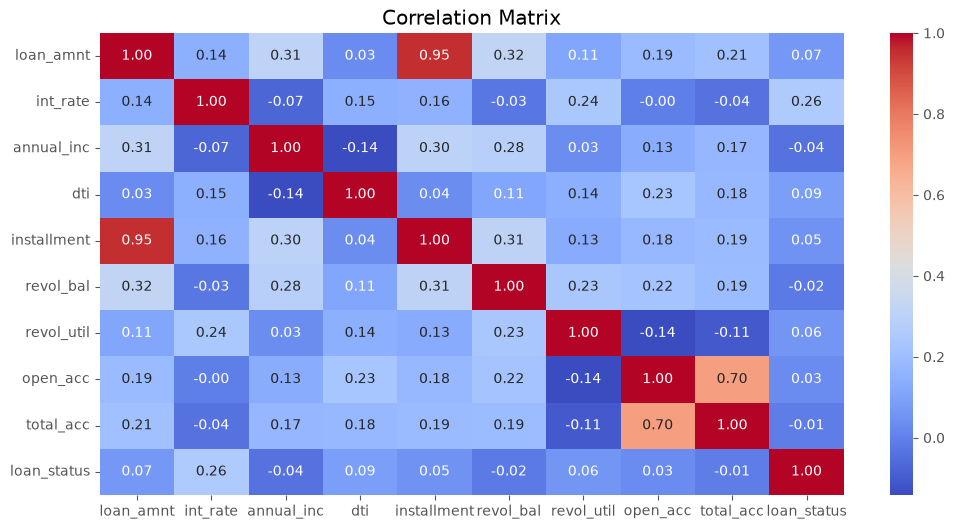

In [82]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

# Phase 2 Summary

## Dataset Overview

- Dataset contains over 2.26 million loan records.
- Total features: 145.
- Memory usage: approximately 5.5 GB.
- No duplicate records were identified.

## Data Quality

- 113 columns contain missing values.
- Several columns contain more than 95% missing values and will be evaluated during preprocessing.
- Some columns contain only a single unique value.

## Target Variable

- The original target contains multiple loan statuses.
- A binary target was created for exploratory analysis using:
  - Fully Paid
  - Charged Off

## Key Business Insights

- Loan grade is one of the strongest indicators of default.
- Higher interest rates are associated with higher default rates.
- Home ownership shows moderate differences in default behavior.
- Loan purpose influences default risk.
- Loan amount alone is not a strong predictor.

## Correlation Insights

- Loan amount and installment are highly correlated.
- Open accounts and total accounts are strongly correlated.
- Interest rate shows the strongest linear relationship with loan default among the selected features.

## Next Steps

- Handle missing values.
- Remove data leakage columns.
- Engineer useful features.
- Encode categorical variables.
- Build preprocessing pipeline.
- Train baseline machine learning models.